<a href="https://colab.research.google.com/github/Seanatist/Seanatist/blob/main/BOSTON_HOUSING_PRICE_DATASET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression

In [ ]:
cols = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT','MEDV']
df = pd.read_csv("house Prediction Data Set (1).csv", header=None, names=cols, sep=r'\s+')

In [ ]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


**Data cleaning**

In [ ]:
df.drop_duplicates(inplace=True) #droping of duplicates

In [ ]:
df.isnull().sum() #checking of null values

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


**Data Preprocessing**

In [ ]:
# IQR outlier detection & capping
# Select only numerical columns, excluding 'CHAS' (binary), 'MEDV' (original target), and 'TARGET' (binarised target)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
exclude_cols = ['CHAS', 'MEDV', 'TARGET']
feature_cols = [col for col in numerical_cols if col not in exclude_cols]

for col in feature_cols:
    Q1, Q3 = df[col].quantile(.25), df[col].quantile(.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers capped for numerical feature columns.")

Outliers capped for numerical feature columns.


In [ ]:
df['TARGET'] = (df['MEDV'] > df['MEDV'].median()).astype(int)  # Binarise target

In [ ]:
# Define features (X) and target (y)
X = df[feature_cols]
y = df['TARGET']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (506, 12)
Target (y) shape: (506,)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled features (X_scaled) shape:", X_scaled.shape)

Scaled features (X_scaled) shape: (506, 12)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)   # Train/test split

**EDA**

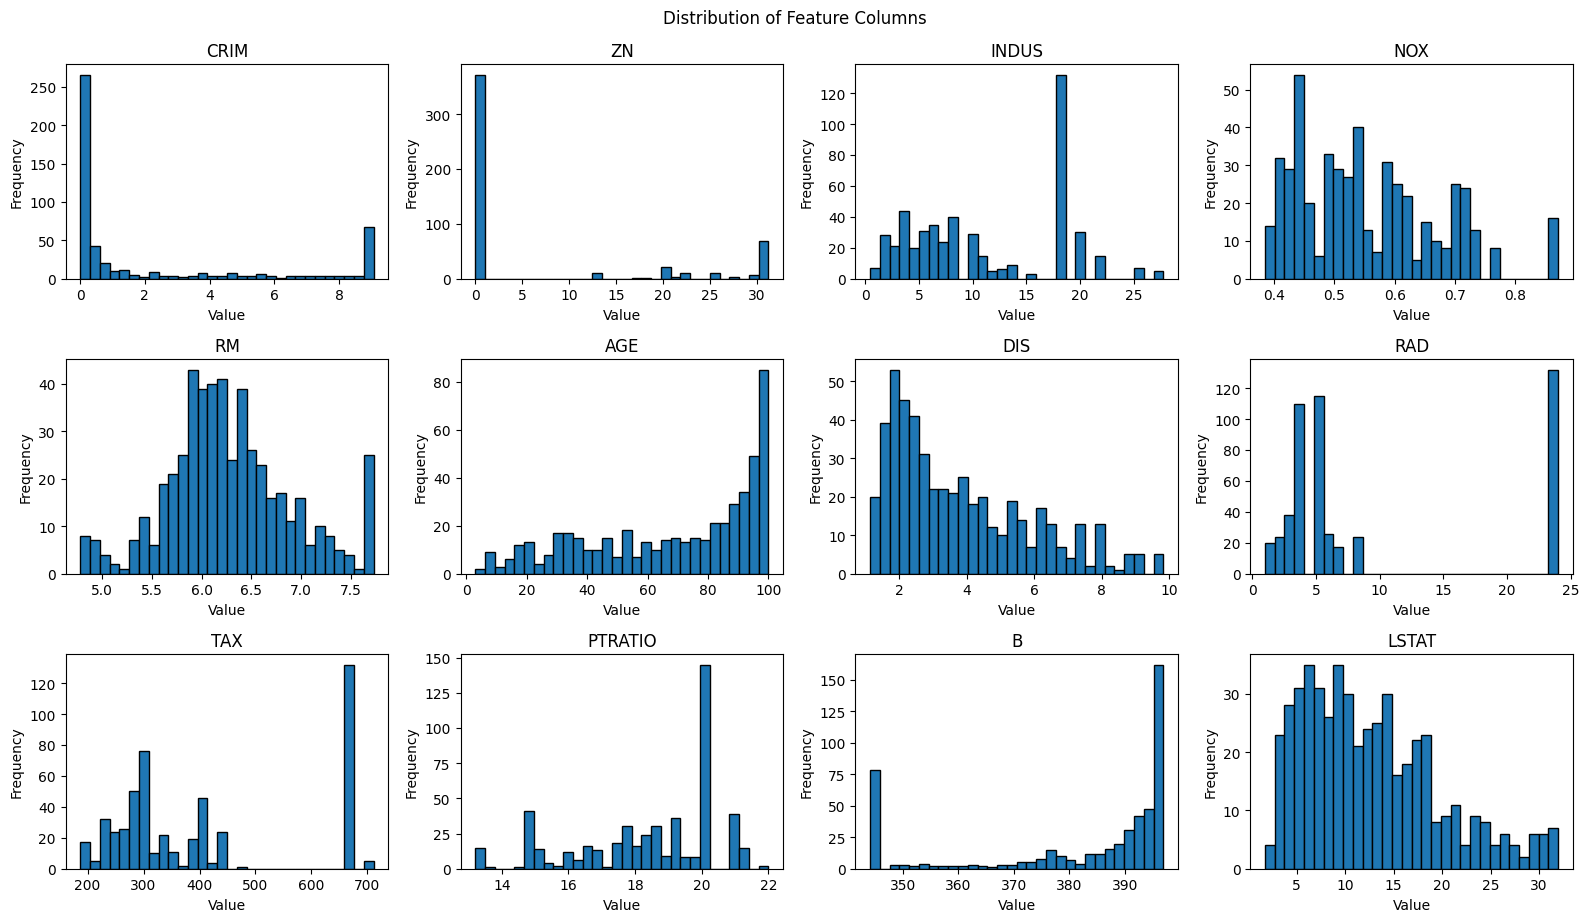

In [ ]:
n_features = len(feature_cols)
n_cols = 4  # Number of columns for subplots
n_rows = (n_features + n_cols - 1) // n_cols  # Calculate number of rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Distribution of Feature Columns', y=1.02) # Add a main title
plt.savefig("eda_1_feature_distributions.png")
plt.show()

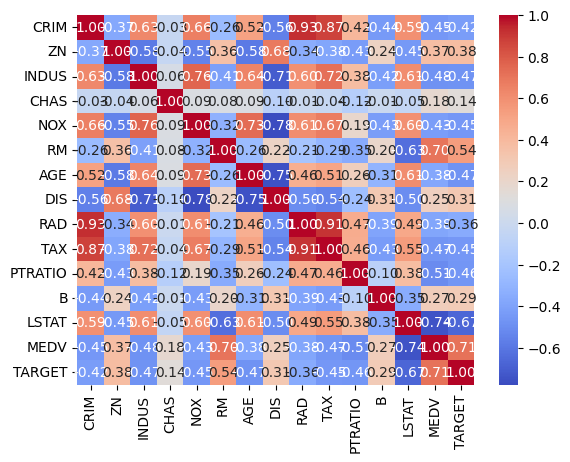

In [ ]:
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.savefig("eda_2_correlation.png")

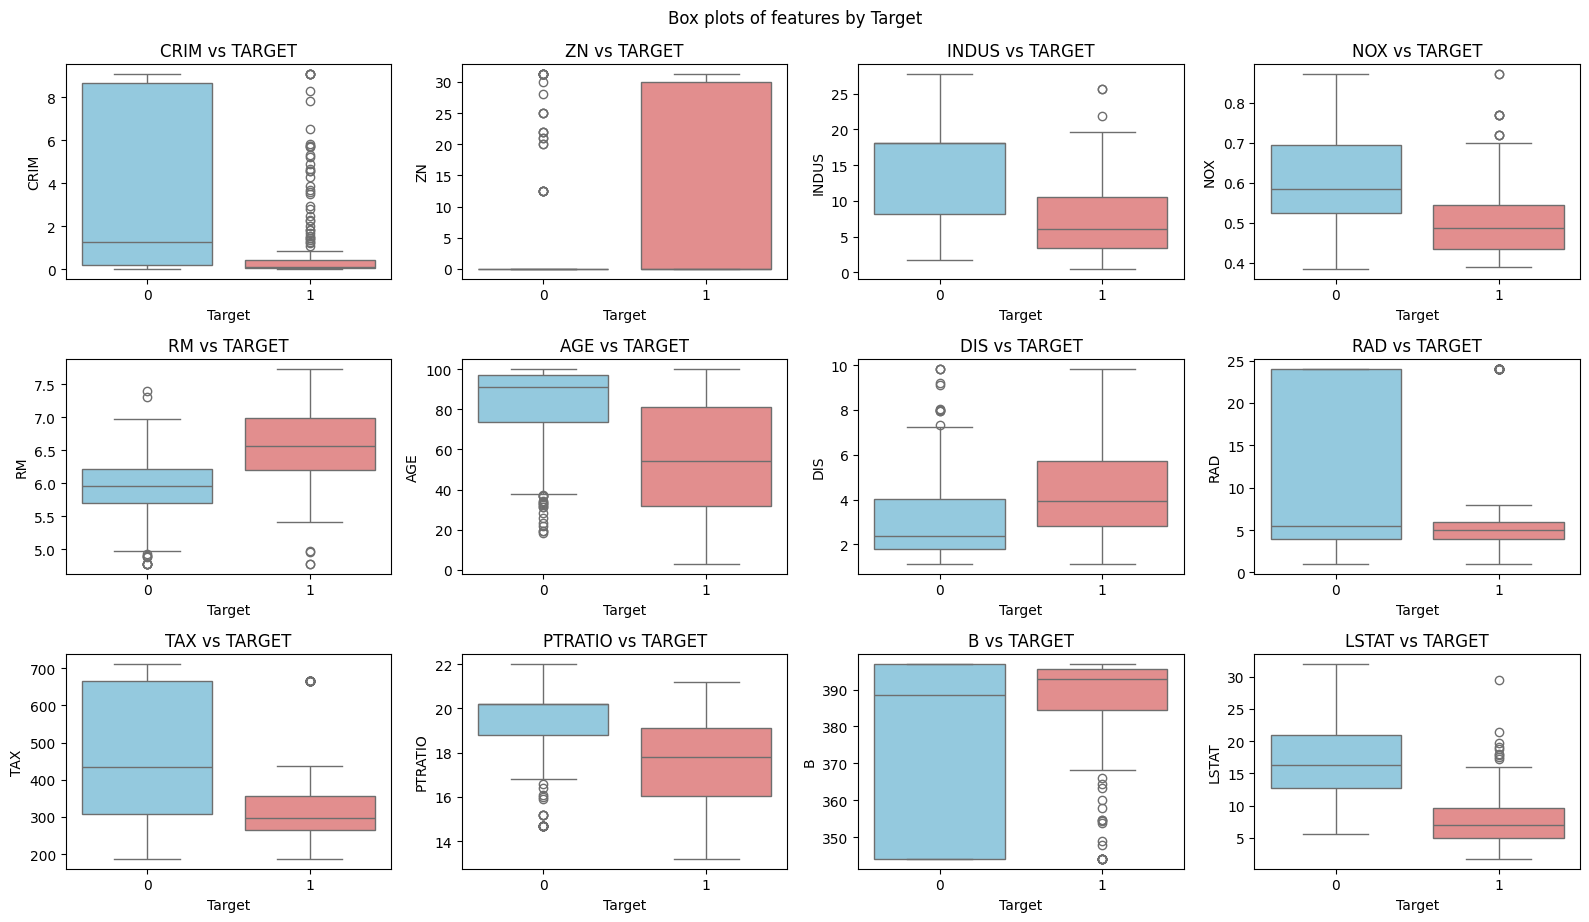

In [ ]:
n_features = len(feature_cols)
n_cols = 4  # Number of columns for subplots
n_rows = (n_features + n_cols - 1) // n_cols  # Calculate number of rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

palette = {0: 'skyblue', 1: 'lightcoral'} # Define a palette for the target variable with integer keys

for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, x='TARGET', y=col, hue='TARGET', palette=palette, ax=axes[i], legend=False)
    axes[i].set_title(f'{col} vs TARGET')
    axes[i].set_xlabel('Target')
    axes[i].set_ylabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Box plots of features by Target', y=1.02)
plt.savefig("eda_3_boxplots_by_target.png")
plt.show()

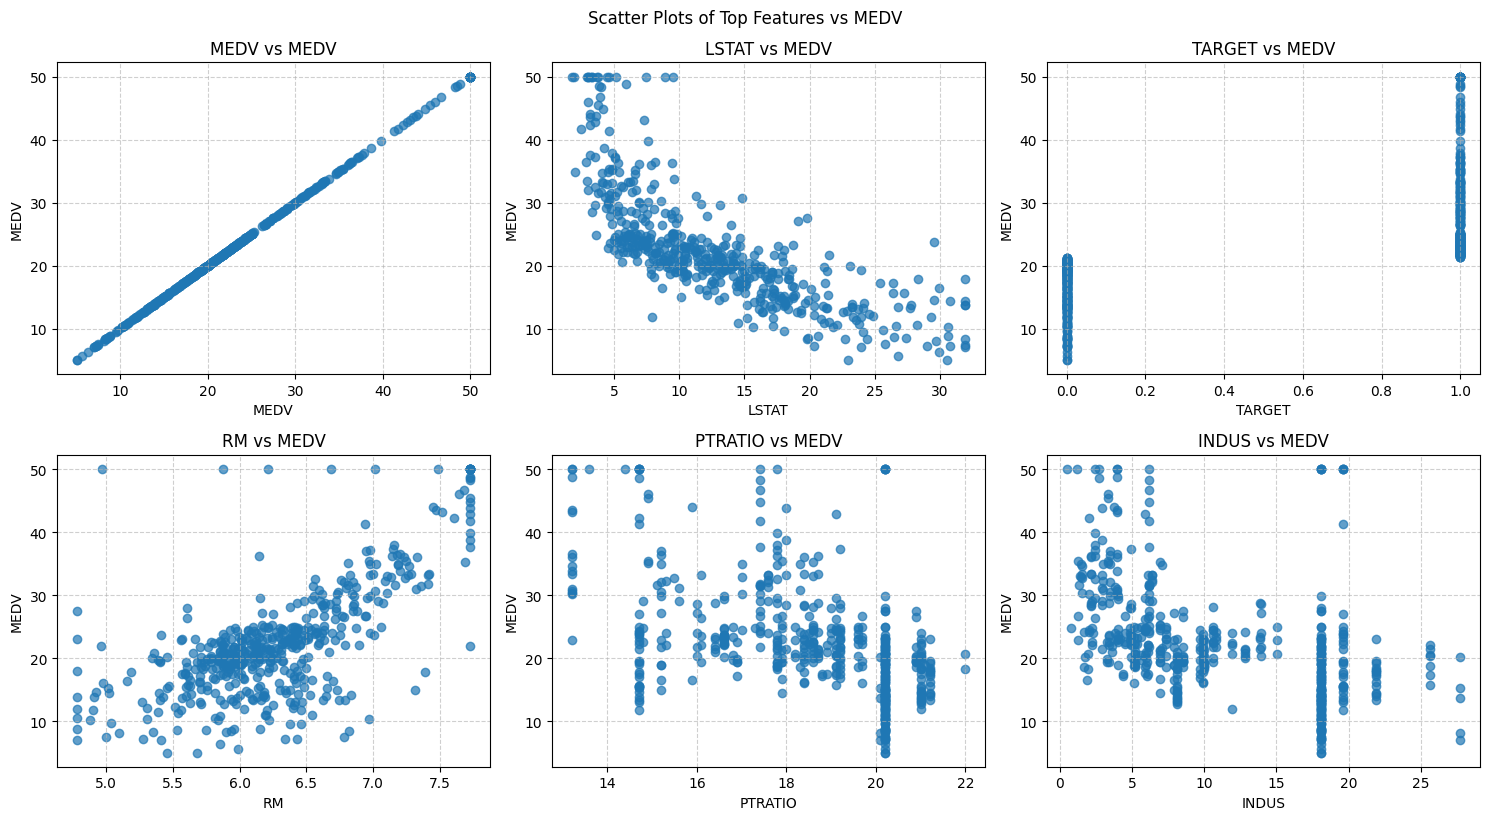

In [ ]:
top_feats = corr['MEDV'].abs().nlargest(6).index

n_features_top = len(top_feats)
n_cols = 3  # Number of columns for subplots
n_rows = (n_features_top + n_cols - 1) // n_cols  # Calculate number of rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, feat in enumerate(top_feats):
    axes[i].scatter(df[feat], df['MEDV'], alpha=0.7)
    axes[i].set_title(f'{feat} vs MEDV')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('MEDV')
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Scatter Plots of Top Features vs MEDV', y=1.02)
plt.savefig("eda_4_scatter_top_features.png")
plt.show()

**Train Logistic Regression**

In [ ]:
Model = LogisticRegression(max_iter=1000, random_state=42)
Model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

**Evaluate Model**

In [ ]:
y_pred  = Model.predict(X_test)
y_proba = Model.predict_proba(X_test)[:, 1]

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
print("Cross-validation Scores:", cross_val_score(Model, X_scaled, y, cv=5))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.8824
ROC AUC Score: 0.9585
Cross-validation Scores: [0.85294118 0.84158416 0.77227723 0.99009901 0.71287129]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88        52
           1       0.88      0.88      0.88        50

    accuracy                           0.88       102
   macro avg       0.88      0.88      0.88       102
weighted avg       0.88      0.88      0.88       102



**Plot model results**

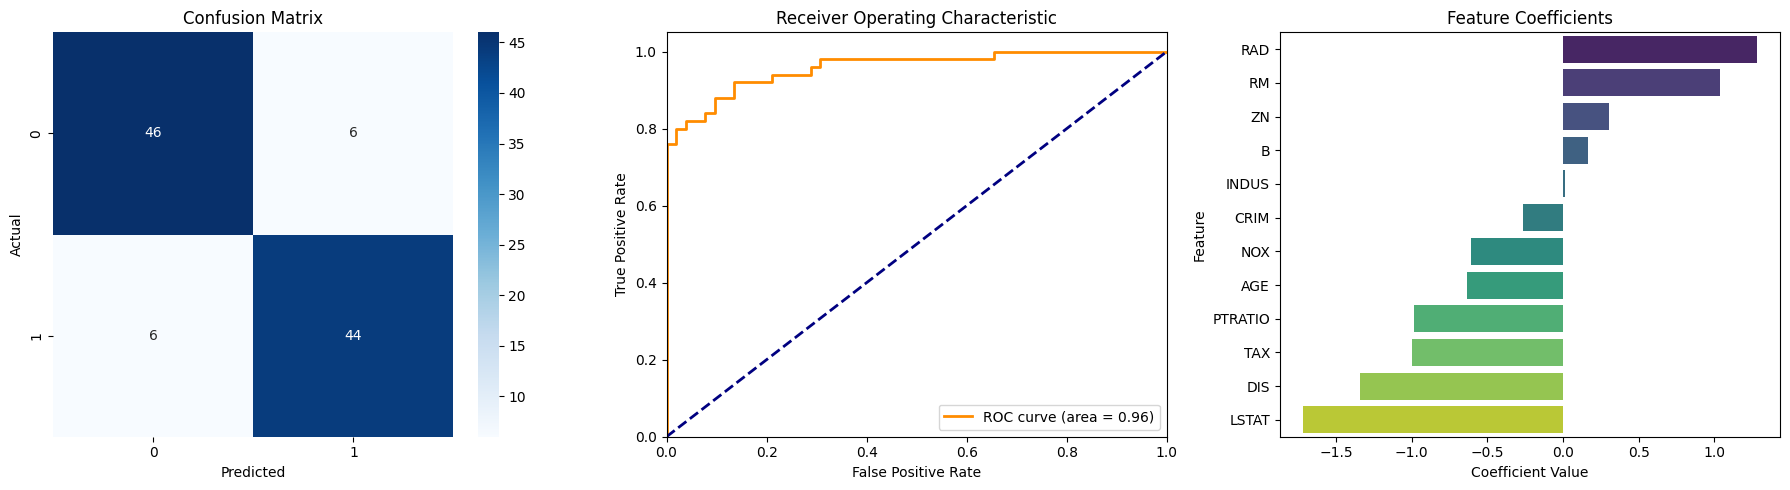

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba))
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic')
axes[1].legend(loc="lower right")

# Feature Coefficients
coefficients = Model.coef_[0]
feature_importance = pd.Series(coefficients, index=feature_cols).sort_values(ascending=False)
sns.barplot(x=feature_importance.values, y=feature_importance.index, hue=feature_importance.index, ax=axes[2], palette='viridis', legend=False)
axes[2].set_title('Feature Coefficients')
axes[2].set_xlabel('Coefficient Value')
axes[2].set_ylabel('Feature')

plt.tight_layout()
plt.savefig("model_results.png")
plt.show()